<a href="https://colab.research.google.com/github/omerfra/AudioSeperator/blob/main/audiosep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Audio Stem Separation - Final Project Submission

**DS25 Final Project - Technion**

**Team Member:** Omer Frank

---

## Abstract

This project presents a novel deep learning model for audio stem separation, the task of isolating individual instruments (e.g., vocals, drums, bass) from a mixed audio track. Our hybrid architecture combines a convolutional U-Net for spatial feature extraction with a recurrent BiLSTM and a self-attention-based Transformer for advanced temporal modeling. Trained on the MUSDB18-HQ dataset, the model learns to predict time-frequency masks for each stem. This notebook details the complete project lifecycle, from data preprocessing and model design to training and evaluation. It serves as both the formal report and an interactive presentation of our work.

---

## 1. Introduction

### 1.1 Environment Setup

This section outlines the necessary steps to configure the computational environment for reproducing the project's results. All required Python libraries are installed using `pip`. Key dependencies include:
*   `musdb` and `stempeg`: For dataset management (MUSDB18-HQ).
*   `librosa` and `torchaudio`: For audio processing and feature extraction.
*   `torch`: The foundational deep learning framework.
*   `numpy`, `scipy`, `matplotlib`: For numerical operations and visualization.
*   `tqdm`: For progress indication during iterative processes.
*   `mir_eval`: For objective evaluation metrics (e.g., SDR).
*   `soundfile`: For audio file I/O.
*   `noisereduce`: Utilized for post-processing noise reduction.

Additionally, `ffmpeg`, a critical multimedia framework, is installed to support `librosa`'s audio loading capabilities.


In [ ]:
# Install required packages
!pip install -q musdb stempeg librosa torch torchaudio numpy scipy matplotlib tqdm mir_eval soundfile noisereduce mermaid-magic --quiet
!apt-get install -qq ffmpeg --quiet

### 1.2 Library Imports

Following environment setup, essential Python libraries are imported to provide necessary functionalities for the project. This adheres to standard coding practices, enhancing readability and modularity. Key imported modules facilitate core deep learning operations, data handling, and audio processing:
*   `torch` and `torch.nn`: Fundamental components for neural network construction and operations.
*   `torch.utils.data.Dataset` and `DataLoader`: PyTorch utilities crucial for efficient data loading and batching.
*   `librosa`: A comprehensive library for audio analysis, including feature extraction like spectrogram generation.
*   `musdb`: Provides an interface for seamless interaction with the MUSDB18-HQ dataset.
*   `matplotlib.pyplot`: Used for generating various data visualizations and plots.
*   `google.colab.drive.mount`: Specifically included for Google Colab environments to access external datasets stored in Google Drive.


In [ ]:
import os
import numpy as np
import random
from typing import Tuple, List, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.amp import autocast, GradScaler

import librosa
import librosa.display
import musdb
import soundfile as sf
import noisereduce as nr

import matplotlib.pyplot as plt
from IPython.display import Audio, display, clear_output
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
%load_ext mermaid_magic

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

### 1.3 Reproducibility

Ensuring the reproducibility of experimental results is paramount in machine learning research. This involves minimizing sources of stochasticity to guarantee that identical inputs yield identical outputs. The primary sources of randomness in deep learning models often stem from initial weight initialization and data shuffling mechanisms.

To address this, a `set_seed` function is implemented to fix the random seeds across multiple libraries and computational backends:
*   Python's built-in `random` module.
*   NumPy, for array operations.
*   PyTorch, covering both CPU and GPU operations.

Furthermore, specific CUDA configurations (`torch.backends.cudnn.deterministic = True`, `torch.backends.cudnn.benchmark = False`) are set to enforce deterministic behavior on NVIDIA GPUs. The primary computational device (`DEVICE`) is also configured to leverage a CUDA-enabled GPU if available, falling back to CPU otherwise.


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

## 2. Related Work

Audio source separation has seen significant advancements with the advent of deep learning. Early approaches often relied on classical signal processing techniques combined with Non-negative Matrix Factorization (NMF) (Févotte et al., 2009). However, deep neural networks have largely surpassed these methods by learning complex mappings from mixed audio to individual sources.

The U-Net architecture (Ronneberger et al., 2015), initially developed for biomedical image segmentation, has proven highly effective in the time-frequency domain for audio tasks. Its symmetric encoder-decoder structure with skip connections allows for the capture of both high-level semantic information and fine-grained temporal details, which are crucial for reconstructing high-fidelity audio (Jansson et al., 2017; Stöter et al., 2019).

Recurrent Neural Networks (RNNs), particularly Long Short-Term Memory (LSTM) networks, are well-suited for modeling temporal dependencies in sequential data like audio. Bidirectional LSTMs (BiLSTMs) enhance this capability by processing sequences in both forward and backward directions, capturing long-range dependencies more effectively (Graves et al., 2005). Models like Open-Unmix (Stöter et al., 2019) successfully integrate BiLSTMs at the bottleneck of U-Net-like structures for music source separation.

More recently, the Transformer architecture (Vaswani et al., 2017), based entirely on self-attention mechanisms, has revolutionized sequence modeling in Natural Language Processing and Computer Vision. Its ability to model global dependencies efficiently, without the sequential processing constraints of RNNs, makes it an attractive candidate for capturing long-range contextual information in audio. Incorporating Transformers into U-Net-based architectures offers a promising direction for further improving separation quality by leveraging both local (convolutional) and global (attention-based) feature interactions.


---

### References
*   Févotte, C., Bertin, N., & Durrieu, J. L. (2009). Nonnegative matrix factorization with the Itakura-Saito divergence: With application to music analysis. *Neural computation*, 21(3), 793-830.
*   Graves, A., & Schmidhuber, J. (2005). Framewise phoneme classification with bidirectional LSTM and other neural network architectures. *Neural Networks*, 18(5-6), 602-610.
*   Jansson, A., Meseguer-Broz, J. P., Bock, S., Stöter, F. R., Mimilakis, S. I. D., & Müller, M. (2017). Singing voice separation with deep U-Net convolutional networks. In *ISMIR*.
*   Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. In *Medical Image Computing and Computer-Assisted Intervention (MICCAI)*.
*   Stöter, F. R., Liutkus, A., & Fitzgerald, D. (2019). Open-Unmix: A reference implementation for music source separation. *Journal of Open Source Software*, 4(41), 1667.
*   Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017). Attention is all you need. In *Advances in neural information processing systems*.

---

## 3. Configuration and Hyperparameters

Hyperparameters are external configuration variables that are set prior to the commencement of the learning process. Unlike model parameters, which are learned during training, hyperparameters directly influence the model's architecture, training dynamics, and data handling strategies. A centralized configuration approach, as implemented in this section, is a best practice for enhancing experimental transparency, reproducibility, and ease of modification.

This section consolidates all critical configuration variables for our experimentation, categorized as follows:
*   **Audio Parameters:** Define the fundamental characteristics of audio processing, including the sample rate, Constant-Q Transform (CQT) settings (e.g., `N_BINS`, `BINS_PER_OCTAVE`, `F_MIN`), and the `SEGMENT_LENGTH` for training samples.
*   **Model Parameters:** Specify the structural aspects of the `StemSeparationNet`, such as the number of output stems (`N_STEMS`), the channel dimensions of the encoder (`ENCODER_CHANNELS`), the number of attention heads (`ATTENTION_HEADS`), and `DROPOUT_RATE` for regularization.
*   **Training Parameters:** Govern the optimization process, encompassing `BATCH_SIZE`, `NUM_EPOCHS`, initial `LEARNING_RATE` and maximum learning rate (`MAX_LR`) for the CosineAnnealingWarmRestarts scheduler, `WEIGHT_DECAY`, `GRADIENT_CLIP`, and `EARLY_STOP_PATIENCE`.
*   **Loss Weights:** Determine the relative importance of individual components within the composite `SeparationLoss` function (e.g., `MASK_LOSS_WEIGHT`, `SOURCE_LOSS_WEIGHT`, `LOG_LOSS_WEIGHT`, `SDR_LOSS_WEIGHT`, and stem-specific weights).
*   **Data Augmentation:** Control the application and parameters of data augmentation techniques, including pitch shifting (`USE_PITCH_SHIFT`, `PITCH_SHIFT_RANGE`, `PITCH_SHIFT_PROB`) and time stretching (`USE_TIME_STRETCH`, `TIME_STRETCH_RANGE`, `TIME_STRETCH_PROB`), and `GAIN_RANGE`.
*   **Paths:** Specify file system locations for the dataset (`MUSDB_PATH`), model checkpoints (`CHECKPOINT_DIR`), and experimental results (`RESULTS_DIR`).


In [ ]:
# ============================================
# AUDIO PARAMETERS
# ============================================
SAMPLE_RATE = 44100
HOP_LENGTH = 512
N_BINS = 756
BINS_PER_OCTAVE = 84
F_MIN = 32.7
SEGMENT_LENGTH = 10
SEGMENT_SAMPLES = SAMPLE_RATE * SEGMENT_LENGTH

# ============================================
# MODEL PARAMETERS
# ============================================
N_STEMS = 4
STEM_NAMES = ['vocals', 'drums', 'bass', 'other']
ENCODER_CHANNELS = [1, 32, 64, 128, 256, 512]
ATTENTION_HEADS = 8
DROPOUT_RATE = 0.15
USE_DECODER_ATTENTION = True
DECODER_ATTENTION_LEVELS = [256, 128]

# ============================================
# TRAINING PARAMETERS
# ============================================
BATCH_SIZE = 6
NUM_EPOCHS = 200
LEARNING_RATE = 5e-5
MAX_LR = 3e-4
WEIGHT_DECAY = 5e-5
GRADIENT_CLIP = 0.5
WARMUP_PCT = 0.1
EARLY_STOP_PATIENCE = 45

# ============================================
# LOSS WEIGHTS
# ============================================
MASK_LOSS_WEIGHT = 1.0
SOURCE_LOSS_WEIGHT = 0.5
LOG_LOSS_WEIGHT = 0.3
SDR_LOSS_WEIGHT = 0.1

# Stem-specific weights
STEM_WEIGHTS = {'vocals': 2.0, 'drums': 1.0, 'bass': 1.0, 'other': 0.8}

# ============================================
# DATA AUGMENTATION
# ============================================
USE_PITCH_SHIFT = True
PITCH_SHIFT_RANGE = (-2, 2)
PITCH_SHIFT_PROB = 0.3
USE_TIME_STRETCH = True
TIME_STRETCH_RANGE = (0.9, 1.1)
TIME_STRETCH_PROB = 0.3
GAIN_RANGE = (0.7, 1.3)

# ============================================
# PATHS
# ============================================
NUM_WORKERS = 12
USE_FULL_DATASET = True
MUSDB_PATH = '/content/drive/MyDrive/Data/musdb18-hq'
CHECKPOINT_DIR = '/content/drive/MyDrive/Data1/stem_separation_transformer'
RESULTS_DIR = './results'
USE_ATTENTION = True

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Encoder: {ENCODER_CHANNELS}")
print(f"Decoder attention: {DECODER_ATTENTION_LEVELS}")
print(f"Stem weights: {STEM_WEIGHTS}")
print(f"LR: {LEARNING_RATE} -> {MAX_LR} (CosineAnnealingWarmRestarts)")
print("="*60)

## 4. Data Loading

The efficacy of any deep learning model is critically dependent on the quality and characteristics of its training data. For this project, we utilize the **MUSDB18-HQ dataset**, a widely recognized benchmark in the field of music source separation. This dataset comprises 150 professionally produced music tracks, each meticulously separated into a main mixture and its constituent four stems: `vocals`, `drums`, `bass`, and `other`. The high-quality (HQ) designation signifies uncompressed audio files, crucial for precise source separation tasks.

The data loading process leverages the `musdb` Python library. The system first attempts to load the full-length, high-quality WAV files from a specified local or mounted Google Drive path (`MUSDB_PATH`). In cases where the full dataset is unavailable or for rapid prototyping, a fallback mechanism is implemented to download and utilize a smaller, 7-second excerpt version of the dataset.

Upon successful loading, the dataset is programmatically partitioned into distinct subsets for model development and evaluation:
*   **Training Set (`train`):** Used for iterative model weight optimization.
*   **Validation Set (`valid`):** Utilized for hyperparameter tuning and early stopping criteria during training.
*   **Test Set (`test`):** Reserved for the final, unbiased evaluation of the trained model's performance.



In [ ]:
print("Loading MUSDB18-HQ...")
if USE_FULL_DATASET and os.path.exists(MUSDB_PATH):
    mus_train = musdb.DB(root=MUSDB_PATH, subsets='train', split='train', is_wav=True)
    mus_valid = musdb.DB(root=MUSDB_PATH, subsets='train', split='valid', is_wav=True)
    mus_test = musdb.DB(root=MUSDB_PATH, subsets='test', is_wav=True)
    print(f"Train: {len(mus_train.tracks)}, Valid: {len(mus_valid.tracks)}, Test: {len(mus_test.tracks)}")
else:
    mus_train = musdb.DB(download=True, subsets='train', split='train')
    mus_valid = musdb.DB(download=True, subsets='train', split='valid')
    mus_test = musdb.DB(download=True, subsets='test')
    print("Using 7s excerpts")

## 5. Data Preparation and Preprocessing


#### 5.1 The PyTorch Dataset Class

The `torch.utils.data.Dataset` class serves as a fundamental abstraction in PyTorch for handling data samples. Our custom `MUSDB18Dataset` subclass is designed to efficiently manage and preprocess the MUSDB18-HQ audio data, transforming raw audio tracks into a format suitable for neural network consumption. The dataset class performs several critical operations:

1.  **Audio Loading and Caching:** All audio tracks are pre-loaded into memory at initialization. This strategy significantly reduces I/O bottlenecks during training, ensuring faster data access.
2.  **Audio Segmentation:** To facilitate efficient batch processing and introduce variability, random 10-second segments are extracted from longer audio tracks during training. This segmentation also functions as a form of data augmentation, exposing the model to diverse parts of each track.
3.  **Data Augmentation:** To improve the model's generalization capabilities and robustness to variations in musical recordings, several audio augmentation techniques are applied to training segments:
    *   **Gain Adjustment:** Random scaling of audio amplitude.
    *   **Pitch Shifting:** Alteration of the audio's perceived pitch without changing its tempo.
    *   **Time Stretching:** Modification of the audio's tempo without altering its pitch.
4.  **Feature Extraction (Constant-Q Transform):** Raw audio waveforms are converted from the time domain to a time-frequency representation using the **Constant-Q Transform (CQT)**. CQT is particularly advantageous for music analysis due to its logarithmically spaced frequency bins, which align more closely with human auditory perception and musical pitch scales. The neural network subsequently learns to predict source masks directly from these CQT spectrograms.


In [ ]:
class MUSDB18Dataset(Dataset):
    """Dataset for MUSDB18-HQ with augmentation."""

    def __init__(self, mus_db, segment_length=6.0, sample_rate=44100,
                 hop_length=512, n_bins=756, bins_per_octave=84, f_min=32.7,
                 random_segments=True, preload=True, augment=True):
        self.tracks = list(mus_db.tracks)
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        self.hop_length = hop_length
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.f_min = f_min
        self.random_segments = random_segments
        self.augment = augment
        self.segment_samples = int(segment_length * sample_rate)
        self.stem_names = ['vocals', 'drums', 'bass', 'other']
        self.samples_per_track = 8 if random_segments else 2

        self.cached_audio = []
        if preload:
            print(f"Pre-loading {len(self.tracks)} tracks...")
            for track in tqdm(self.tracks, desc='Loading'):
                mix = track.audio.mean(axis=1).astype(np.float32)
                stems = [track.targets[s].audio.mean(axis=1).astype(np.float32)
                        for s in self.stem_names]
                self.cached_audio.append((mix, stems))
            print(f"✓ Loaded {len(self.tracks)} tracks")

    def __len__(self):
        return len(self.tracks) * self.samples_per_track

    def _extract_segment(self, audio, start=None):
        total = len(audio)
        if total < self.segment_samples:
            return np.pad(audio, (0, self.segment_samples - total))
        if start is None:
            start = np.random.randint(0, total - self.segment_samples) if self.random_segments else 0
        return audio[start:start + self.segment_samples]

    def _compute_cqt(self, audio):
        cqt = librosa.cqt(audio, sr=self.sample_rate, hop_length=self.hop_length,
                         n_bins=self.n_bins, bins_per_octave=self.bins_per_octave, fmin=self.f_min)
        mag = np.abs(cqt).astype(np.float32)
        phase = np.angle(cqt).astype(np.float32)
        log_mag = np.log1p(mag).astype(np.float32)
        return log_mag, mag, phase

    def _apply_augmentation(self, mix_audio, stem_audios):
        """Enhanced augmentation."""
        # Random gain
        gain = np.random.uniform(*GAIN_RANGE)
        mix_audio = mix_audio * gain
        stem_audios = [s * gain for s in stem_audios]

        # Pitch shift
        if USE_PITCH_SHIFT and np.random.random() < PITCH_SHIFT_PROB:
            n_steps = np.random.uniform(*PITCH_SHIFT_RANGE)
            mix_audio = librosa.effects.pitch_shift(mix_audio, sr=self.sample_rate, n_steps=n_steps)
            stem_audios = [librosa.effects.pitch_shift(s, sr=self.sample_rate, n_steps=n_steps)
                          for s in stem_audios]

        # Time stretch
        if USE_TIME_STRETCH and np.random.random() < TIME_STRETCH_PROB:
            rate = np.random.uniform(*TIME_STRETCH_RANGE)
            mix_audio = librosa.effects.time_stretch(mix_audio, rate=rate)
            stem_audios = [librosa.effects.time_stretch(s, rate=rate) for s in stem_audios]

            # Fix length
            target_len = self.segment_samples
            if len(mix_audio) > target_len:
                start = np.random.randint(0, len(mix_audio) - target_len)
                mix_audio = mix_audio[start:start + target_len]
                stem_audios = [s[start:start + target_len] for s in stem_audios]
            elif len(mix_audio) < target_len:
                mix_audio = np.pad(mix_audio, (0, target_len - len(mix_audio)))
                stem_audios = [np.pad(s, (0, target_len - len(s))) for s in stem_audios]

        return mix_audio, stem_audios

    def __getitem__(self, idx):
        track_idx = idx % len(self.tracks)
        mix_audio, stem_audios = self.cached_audio[track_idx]
        mix_audio, stem_audios = mix_audio.copy(), [s.copy() for s in stem_audios]

        total = len(mix_audio)
        if self.random_segments and total > self.segment_samples:
            start = np.random.randint(0, total - self.segment_samples)
        else:
            sample_in_track = idx // len(self.tracks)
            start = min(sample_in_track * self.segment_samples, max(0, total - self.segment_samples))

        mix_seg = self._extract_segment(mix_audio, start)
        stem_segs = [self._extract_segment(s, start) for s in stem_audios]

        if self.augment and self.random_segments:
            mix_seg, stem_segs = self._apply_augmentation(mix_seg, stem_segs)

        mix_audio_seg = mix_seg.copy()
        stem_audio_segs = [s.copy() for s in stem_segs]

        mix_log_mag, mix_mag, mix_phase = self._compute_cqt(mix_seg)
        stem_log_mags, stem_mags = [], []
        for s in stem_segs:
            slm, sm, _ = self._compute_cqt(s)
            stem_log_mags.append(slm)
            stem_mags.append(sm)

        return {
            'mixture': torch.from_numpy(mix_log_mag).unsqueeze(0),
            'stems': torch.from_numpy(np.stack(stem_log_mags)),
            'mixture_mag': torch.from_numpy(mix_mag),
            'stems_mag': torch.from_numpy(np.stack(stem_mags)),
            'mixture_phase': torch.from_numpy(mix_phase),
            'stems_audio': torch.from_numpy(np.stack(stem_audio_segs)),
            'mixture_audio': torch.from_numpy(mix_audio_seg),
        }

print("MUSDB18Dataset defined.")

#### 5.2 The PyTorch DataLoader

While the `Dataset` class defines how individual data samples are accessed and preprocessed, the `torch.utils.data.DataLoader` class orchestrates the efficient delivery of these samples to the model during training and evaluation. Its primary functions include:

*   **Batching:** Grouping individual data samples into mini-batches, which is essential for optimizing computational efficiency on accelerators like GPUs and for stable gradient estimation during training.
*   **Shuffling:** Randomizing the order of data samples within each epoch (`shuffle=True` for training loaders) to prevent the model from learning spurious correlations arising from data order.
*   **Parallel Data Loading:** Utilizing multiple worker processes (`num_workers`) to load and preprocess data in parallel, thereby minimizing potential bottlenecks where the GPU might idle while waiting for data.
*   **Memory Pinning:** Employing `pin_memory=True` to automatically transfer fetched data tensors to CUDA-pinned memory, which can accelerate data transfer to the GPU.
*   **Drop Last Batch:** For training, `drop_last=True` ensures that all mini-batches have a consistent size, simplifying model architecture design and training logic.

In this project, three `DataLoader` instances are instantiated:
*   `train_loader`: Configured with `shuffle=True` and `drop_last=True` for robust model training.
*   `valid_loader`: Used for monitoring model performance on unseen data during training, with `shuffle=False` as order is not critical for evaluation.
*   `test_loader`: Employed for final, unbiased performance assessment after training is complete, also with `shuffle=False`.



In [ ]:
# Create datasets
train_dataset = MUSDB18Dataset(mus_train, SEGMENT_LENGTH, SAMPLE_RATE, HOP_LENGTH,
                                  N_BINS, BINS_PER_OCTAVE, F_MIN, True, True, True)
valid_dataset = MUSDB18Dataset(mus_valid, SEGMENT_LENGTH, SAMPLE_RATE, HOP_LENGTH,
                                  N_BINS, BINS_PER_OCTAVE, F_MIN, False, True, False)
test_dataset = MUSDB18Dataset(mus_test, SEGMENT_LENGTH, SAMPLE_RATE, HOP_LENGTH,
                                 N_BINS, BINS_PER_OCTAVE, F_MIN, False, True, False)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")

## 6. Model Architecture
Our proposed `StemSeparationNet` employs a hybrid deep learning architecture meticulously designed to capture both local spectral characteristics and global temporal dependencies within mixed audio signals. It integrates a convolutional U-Net for efficient spatial feature extraction with advanced recurrent (BiLSTM) and self-attention-based (Transformer) layers, enabling a comprehensive understanding of complex musical structures. This design aims to leverage the strengths of each component to achieve superior audio source separation performance.





### 6.1 Temporal Modeling: BiLSTM

Bidirectional Long Short-Term Memory (BiLSTM) networks, a specialized form of Recurrent Neural Network (RNN), are inherently adept at processing sequential data, making them highly suitable for audio analysis. Their unique ability to process input sequences in both forward and backward directions allows them to capture long-range temporal dependencies and context from both past and future information within a sequence. This characteristic is vital for understanding musical structure and transient events in audio.

In our architecture, the `BiLSTMBlock` is strategically positioned at the bottleneck of the U-Net. This placement enables the BiLSTM to operate on the most abstract and compressed feature representations from the encoder. The input feature map `(B, C, H, W)` is reshaped to `(B*H, W, C)`, effectively treating the time dimension (`W`) as the sequence length for the BiLSTM. A 3-layer BiLSTM is then applied, allowing the model to learn intricate temporal relationships across the entire 10-second audio segment, thus enriching the feature representation with global temporal context before reconstruction.



In [ ]:
class BiLSTMBlock(nn.Module):
    """Bidirectional LSTM for temporal modeling (Open-Unmix style).

    This captures long-range temporal dependencies that CNNs miss.
    Applied along the time axis of the spectrogram.
    """

    def __init__(self, input_dim, hidden_dim, num_layers=3, dropout=0.4):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Stacked BiLSTM layers
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim // 2,  # Bidirectional doubles this
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Output projection back to input dim
        self.output_proj = nn.Linear(hidden_dim, input_dim)

        # Layer norm for stability
        self.layer_norm = nn.LayerNorm(input_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """Input: (B, C, H, W) -> Output: (B, C, H, W)

        Processes along W (time) dimension for each frequency bin.
        """
        B, C, H, W = x.shape

        # Reshape: (B, C, H, W) -> (B*H, W, C) to process time for each freq bin
        x = x.permute(0, 2, 3, 1)  # (B, H, W, C)
        x = x.reshape(B * H, W, C)  # (B*H, W, C)

        # Store residual
        residual = x

        # Project to hidden dim
        x = self.input_proj(x)  # (B*H, W, hidden_dim)

        # BiLSTM
        x, _ = self.lstm(x)  # (B*H, W, hidden_dim)

        # Project back
        x = self.output_proj(x)  # (B*H, W, C)
        x = self.dropout(x)

        # Residual connection + layer norm
        x = self.layer_norm(x + residual)

        # Reshape back: (B*H, W, C) -> (B, C, H, W)
        x = x.reshape(B, H, W, C)  # (B, H, W, C)
        x = x.permute(0, 3, 1, 2)  # (B, C, H, W)

        return x

print("BiLSTM module defined.")

### 6.2 Global Context: Transformer

While Recurrent Neural Networks excel at sequential modeling, the Transformer architecture, powered by its self-attention mechanism, has emerged as the state-of-the-art for capturing global dependencies across entire input sequences. Unlike RNNs, Transformers can process all elements of a sequence in parallel, allowing them to effectively weigh the importance of any given time step relative to all other time steps, irrespective of their distance. This capability is crucial for understanding long-range contextual relationships within audio signals.

Our model strategically incorporates Transformers in two distinct capacities:
1.  **`BottleneckTransformer`:** This component is applied immediately after the BiLSTM at the U-Net's bottleneck. It consists of a stack of Transformer encoder layers that operate along the time dimension of the feature maps. This provides a refined, globally aware temporal modeling, allowing the network to consolidate long-distance dependencies identified by the BiLSTM and establish a holistic understanding of the audio's temporal structure.
2.  **`DecoderTransformer`:** Integrated within specific levels of the U-Net's decoder path, this lightweight Transformer module performs self-attention over the flattened spatial (time and frequency) dimensions of the feature maps. Its role is to reintroduce and integrate global context during the upsampling and reconstruction phases, ensuring that the separated stems benefit from a comprehensive understanding of the entire audio landscape, thereby enhancing the quality and coherence of the output.


In [ ]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""

    def __init__(self, d_model, max_len=20000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.d_model = d_model

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """x: (B, seq_len, d_model)"""
        seq_len = x.size(1)
        # Dynamically extend PE if needed
        if seq_len > self.pe.size(1):
            pe = torch.zeros(seq_len, self.d_model, device=x.device)
            position = torch.arange(0, seq_len, dtype=torch.float, device=x.device).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, self.d_model, 2, device=x.device).float() * (-np.log(10000.0) / self.d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            x = x + pe.unsqueeze(0)
        else:
            x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)


class TransformerEncoderBlock(nn.Module):
    """Transformer encoder layer with pre-norm."""

    def __init__(self, d_model, nhead=8, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Pre-norm architecture (more stable)
        x_norm = self.norm1(x)
        attn_out, _ = self.self_attn(x_norm, x_norm, x_norm)
        x = x + self.dropout(attn_out)

        x_norm = self.norm2(x)
        x = x + self.ffn(x_norm)
        return x


class BottleneckTransformer(nn.Module):
    """Transformer encoder for bottleneck (after BiLSTM).

    Processes along time dimension for global temporal context.
    """

    def __init__(self, d_model, nhead=8, num_layers=4, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """Input: (B, C, H, W) -> Output: (B, C, H, W)"""
        B, C, H, W = x.shape

        # Reshape: (B, C, H, W) -> (B*H, W, C)
        x = x.permute(0, 2, 3, 1)  # (B, H, W, C)
        x = x.reshape(B * H, W, C)  # (B*H, W, C)

        # Add positional encoding
        x = self.pos_encoding(x)

        # Transformer layers
        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)

        # Reshape back: (B*H, W, C) -> (B, C, H, W)
        x = x.reshape(B, H, W, C)
        x = x.permute(0, 3, 1, 2)

        return x


class DecoderTransformer(nn.Module):
    """Lightweight Transformer for decoder feature maps.

    Applied at specific decoder levels for global context.
    """

    def __init__(self, channels, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.channels = channels
        dim_feedforward = channels * 2  # Smaller FFN for decoder

        self.pos_encoding = PositionalEncoding(channels, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(channels, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        """Input: (B, C, H, W) -> Output: (B, C, H, W)"""
        B, C, H, W = x.shape

        # Flatten spatial dims: (B, C, H, W) -> (B, H*W, C)
        x = x.permute(0, 2, 3, 1).reshape(B, H * W, C)

        # Store residual for skip connection
        residual = x

        # Add positional encoding
        x = self.pos_encoding(x)

        # Transformer layers
        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)

        # Residual connection
        x = x + residual

        # Reshape back: (B, H*W, C) -> (B, C, H, W)
        x = x.reshape(B, H, W, C).permute(0, 3, 1, 2)

        return x

print("Transformer modules defined.")

### 6.3 Spatial Processing: U-Net

The U-Net architecture, initially conceived for precise biomedical image segmentation, has demonstrated remarkable efficacy in audio source separation tasks due to its ability to handle feature hierarchies effectively. Its fundamental design comprises two symmetrical paths:

*   An **Encoder Path:** This contracting path systematically downsamples the input Constant-Q Transform (CQT) spectrogram through a series of convolutional layers and pooling operations. This process progressively extracts increasingly abstract and high-level features while simultaneously expanding the receptive field, thereby capturing broader contextual information within the audio frame.
*   A **Decoder Path:** This expansive path is responsible for reconstructing the separated stem masks. It upsamples the features, gradually recovering the original resolution. A key innovation of the U-Net is its use of **skip connections**, which concatenate feature maps from corresponding levels in the encoder directly to the decoder. These connections are critical for preserving fine-grained, low-level acoustic details that might otherwise be lost during the downsampling process, enabling high-fidelity audio reconstruction.

Our implementation, utilizing `UNetEncoder` and `UNetDecoder` classes, closely follows this paradigm. The encoder is built from `EncoderBlock`s (convolutional layers followed by max-pooling), while the decoder employs `DecoderBlock`s, which incorporate upsampling and integrate skip connections. This modular design effectively combines high-level semantic understanding with precise acoustic localization.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        features = self.conv(x)
        return features, self.pool(features)


class UNetEncoder(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.blocks = nn.ModuleList([EncoderBlock(channels[i], channels[i+1]) for i in range(len(channels)-1)])
    def forward(self, x):
        skips = []
        for block in self.blocks:
            feat, x = block(x)
            skips.append(feat)
        return x, skips


class DecoderBlock(nn.Module):
    """Decoder with optional Transformer."""
    def __init__(self, in_ch, skip_ch, out_ch, use_transformer=False, nhead=4):
        super().__init__()
        self.use_transformer = use_transformer
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch // 2 + skip_ch, out_ch)
        if use_transformer:
            self.transformer = DecoderTransformer(out_ch, nhead=nhead, num_layers=2)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            dh, dw = skip.shape[2] - x.shape[2], skip.shape[3] - x.shape[3]
            x = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
        x = self.conv(torch.cat([x, skip], dim=1))
        if self.use_transformer:
            x = self.transformer(x)
        return x


class UNetDecoder(nn.Module):
    def __init__(self, decoder_channels, skip_channels, transformer_levels=None):
        super().__init__()
        transformer_levels = transformer_levels or []
        self.blocks = nn.ModuleList()
        # `skip_channels` are now passed explicitly.
        for i in range(len(decoder_channels)):
            in_ch = decoder_channels[i]
            s_ch = skip_channels[i]
            out_ch = decoder_channels[i+1] if i < len(decoder_channels) - 1 else s_ch
            use_trans = out_ch in transformer_levels
            self.blocks.append(DecoderBlock(in_ch, s_ch, out_ch, use_transformer=use_trans))

    def forward(self, x, skips):
        # The skips from encoder are ordered from shallow to deep, so reverse them for the decoder
        for block, skip in zip(self.blocks, reversed(skips)):
            x = block(x, skip)
        return x

print("U-Net components defined.")

### 6.4 Assembling the Final Model

The complete `StemSeparationNet` integrates the U-Net, BiLSTM, and Transformer components into a unified end-to-end architecture for music source separation. This hybrid design leverages the complementary strengths of convolutional networks for spatial feature extraction, recurrent networks for local temporal modeling, and self-attention mechanisms for global contextual understanding.

The forward pass through the `StemSeparationNet` proceeds as follows:
1.  **Encoder Stage:** The input CQT spectrogram of the mixed audio is fed into the `UNetEncoder`. This stage progressively reduces the spatial dimensions while increasing channel depth, extracting a hierarchical representation of features.
2.  **Bottleneck Processing (BiLSTM & Transformer):** The most abstract feature map at the U-Net's bottleneck undergoes sequential processing by the `BiLSTMBlock` and then the `BottleneckTransformer`. The BiLSTM captures local temporal dependencies, while the Transformer subsequently refines these features by integrating global temporal context through self-attention.
3.  **Decoder Stage:** The enhanced bottleneck features are then passed to the `UNetDecoder`. This stage, augmented with skip connections from the encoder and internal `DecoderTransformer` layers, reconstructs the feature maps. The skip connections provide crucial low-level details, and the `DecoderTransformer`s help re-integrate global context during upsampling.
4.  **Stem Mask Prediction:** The final output of the decoder is processed by individual `stem_head` modules. Each head, a small convolutional network culminating in a sigmoid activation, predicts a soft mask for one of the four target stems (vocals, drums, bass, other). These masks are designed to be multiplied with the original mixture's magnitude spectrogram to estimate the spectrogram of each isolated stem.


---



In [ ]:
class StemSeparationNet(nn.Module):
    """U-Net with BiLSTM + Transformer (bottleneck and decoder)."""

    def __init__(self, encoder_channels=[1, 32, 64, 128, 256, 512], n_stems=4,
                 dropout=0.1, lstm_layers=3, lstm_hidden=512,
                 trans_layers=4, trans_heads=8, decoder_trans_levels=[256, 128]):
        super().__init__()
        self.n_stems = n_stems
        self.encoder = UNetEncoder(encoder_channels)
        bottleneck_ch = encoder_channels[-1]

        # BiLSTM for temporal modeling
        self.bilstm = BiLSTMBlock(
            input_dim=bottleneck_ch,
            hidden_dim=lstm_hidden,
            num_layers=lstm_layers,
            dropout=0.4
        )

        # Transformer encoder at bottleneck
        self.bottleneck_transformer = BottleneckTransformer(
            d_model=bottleneck_ch,
            nhead=trans_heads,
            num_layers=trans_layers,
            dim_feedforward=bottleneck_ch * 2,
            dropout=dropout
        )

        self.bottleneck_conv = ConvBlock(bottleneck_ch, bottleneck_ch)

        # Decoder with Transformer at specified levels
        decoder_channels = list(reversed(encoder_channels[1:])) # [512, 256, 128, 64, 32]
        skip_channels = list(reversed(encoder_channels[1:]))    # [512, 256, 128, 64, 32]
        self.decoder = UNetDecoder(decoder_channels, skip_channels, decoder_trans_levels)

        decoder_out_ch = encoder_channels[1]
        self.final_up = nn.ConvTranspose2d(decoder_out_ch, decoder_out_ch, kernel_size=2, stride=2)
        self.stem_heads = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(decoder_out_ch, 32, 3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.Conv2d(32, 1, 1), nn.Sigmoid()
            ) for _ in range(n_stems)
        ])

        print(f"StemSeparationNet (BiLSTM + Transformer): {sum(p.numel() for p in self.parameters()):,} params")
        print(f"  Encoder: {encoder_channels}")
        print(f"  BiLSTM: {lstm_layers} layers, hidden={lstm_hidden}")
        print(f"  Bottleneck Transformer: {trans_layers} layers, {trans_heads} heads")
        print(f"  Decoder Transformer levels: {decoder_trans_levels}")

    def forward(self, x):
        original_shape = x.shape

        # Encoder
        bottleneck, skips = self.encoder(x)

        # BiLSTM temporal modeling
        bottleneck = self.bilstm(bottleneck)

        # Transformer for global context
        bottleneck = self.bottleneck_transformer(bottleneck)

        # Conv bottleneck
        bottleneck = self.bottleneck_conv(bottleneck)

        # Decoder with Transformer
        decoded = self.decoder(bottleneck, skips)

        upsampled = self.final_up(decoded)
        if upsampled.shape[2:] != original_shape[2:]:
            upsampled = F.interpolate(upsampled, size=original_shape[2:], mode='bilinear', align_corners=False)
        return torch.cat([head(upsampled) for head in self.stem_heads], dim=1)


# Hyperparameters
LSTM_LAYERS = 3
LSTM_HIDDEN = 512
TRANS_LAYERS = 4
TRANS_HEADS = 8
DECODER_TRANS_LEVELS = [256, 128]

model = StemSeparationNet(
    ENCODER_CHANNELS, N_STEMS, DROPOUT_RATE,
    LSTM_LAYERS, LSTM_HIDDEN,
    TRANS_LAYERS, TRANS_HEADS, DECODER_TRANS_LEVELS
).to(DEVICE)

# Test
print("\nTesting forward pass...")
with torch.no_grad():
    test_in = torch.randn(2, 1, N_BINS, 517).to(DEVICE)
    test_out = model(test_in)
    print(f"Input: {test_in.shape} -> Output: {test_out.shape}")
    print(f"Output range: [{test_out.min():.3f}, {test_out.max():.3f}]")
    print("✓ Model test passed!")

### 6.5 Model Data Flow (Flowchart Representation)

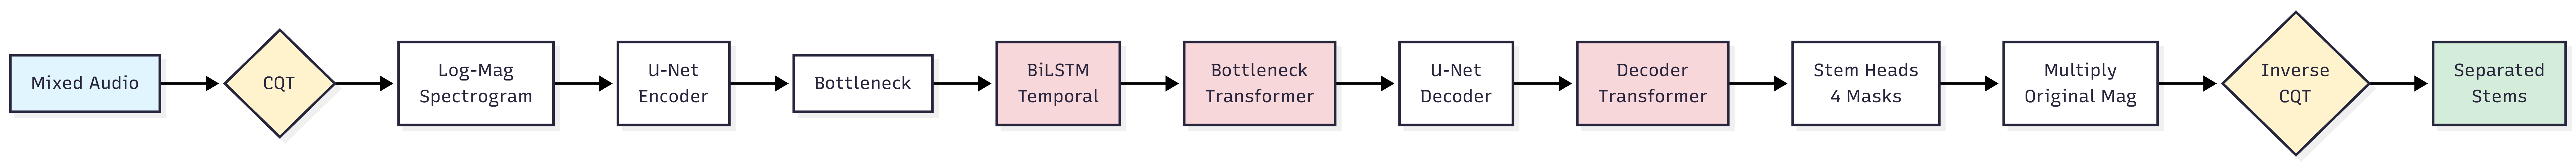

## 7. The Loss Function

The loss function is a pivotal component in training deep learning models, serving as a quantitative measure of the discrepancy between the model's predictions and the true target values. The objective of the training process is to iteratively adjust model parameters to minimize this function. For our audio stem separation task, a multi-objective loss function, encapsulated within the `SeparationLoss` class, is employed. This function represents a weighted sum of several distinct loss components, designed to collectively guide the model towards optimal separation performance:

*   **Mask Loss (L2):** This primary component calculates the Mean Squared Error (MSE) between the model's predicted soft mask for each stem and an "ideal" mask. The ideal mask is dynamically computed by dividing the magnitude spectrogram of each target stem by the sum of all target spectrograms. This encourages the model to generate masks that accurately isolate individual sources.
*   **Source Loss (L1):** This term applies an L1 loss directly to the reconstructed source spectrograms (predicted mask multiplied by the mixture spectrogram) and their corresponding true spectrograms. It promotes accurate magnitude reconstruction of the separated audio components.
*   **Log Magnitude Loss (L1):** Similar to the source loss, but computed on the log-magnitude spectrograms. This formulation often yields better results in audio processing due to the perceptual characteristics of human hearing, which is more sensitive to relative changes in loudness (logarithmic scale).
*   **SI-SDR (Scale-Invariant Source to Distortion Ratio) Loss:** To directly optimize for a perceptually relevant metric, a proxy for the SI-SDR is incorporated into the loss function. SI-SDR is a widely used objective metric for source separation quality. Directly optimizing this value during training has been shown to improve the perceived quality of separated audio. Furthermore, stem-specific weights are applied, with the `vocals` stem receiving a higher weighting, reflecting its often paramount importance in musical contexts.

This composite loss function facilitates a holistic optimization, balancing mask prediction accuracy with both linear and perceptually-motivated magnitude reconstruction, and direct improvement of separation quality via the SI-SDR proxy.


In [ ]:
class SeparationLoss(nn.Module):
    """Multi-objective loss with SI-SDR proxy and stem weighting."""

    def __init__(self, mask_weight=1.0, source_weight=0.5, log_weight=0.3, sdr_weight=0.5,
                 stem_weights=None, eps=1e-8):
        super().__init__()
        self.mask_weight = mask_weight
        self.source_weight = source_weight
        self.log_weight = log_weight
        self.sdr_weight = sdr_weight
        self.stem_weights = stem_weights or {'vocals': 1.0, 'drums': 1.0, 'bass': 1.0, 'other': 1.0}
        self.eps = eps
        self.stem_names = ['vocals', 'drums', 'bass', 'other']
        self.weight_tensor = torch.tensor([self.stem_weights[s] for s in self.stem_names])
        print(f"Loss: mask={mask_weight}, source={source_weight}, log={log_weight}, sdr={sdr_weight}")
        print(f"Stem weights: {self.stem_weights}")

    def forward(self, pred_masks, mixture, target_stems, stems_audio=None, **kwargs):
        mix_linear = torch.expm1(mixture.clamp(min=0))
        stems_linear = torch.expm1(target_stems.clamp(min=0))
        mix_linear_exp = mix_linear.expand_as(stems_linear)

        # Wiener masks
        sum_stems = stems_linear.sum(dim=1, keepdim=True) + self.eps
        ideal_masks = stems_linear / sum_stems

        weights = self.weight_tensor.to(pred_masks.device).view(1, -1, 1, 1)

        # Weighted mask loss
        mask_diff = ((pred_masks - ideal_masks) ** 2) * weights
        mask_loss = mask_diff.mean()

        # Weighted source loss (linear)
        pred_sources = pred_masks * mix_linear_exp
        source_diff = torch.abs(pred_sources - stems_linear) * weights
        source_loss = source_diff.mean()

        # Weighted source loss (log)
        pred_sources_log = torch.log1p(pred_sources)
        log_diff = torch.abs(pred_sources_log - target_stems) * weights
        log_loss = log_diff.mean()

        total_loss = self.mask_weight * mask_loss + self.source_weight * source_loss + self.log_weight * log_loss

        # SI-SDR proxy in spectral domain
        sdr_val = 0.0
        if self.sdr_weight > 0:
            target_energy = (stems_linear ** 2).sum(dim=(2, 3)) + self.eps
            error_energy = ((pred_sources - stems_linear) ** 2).sum(dim=(2, 3)) + self.eps
            spectral_sdr = 10 * torch.log10(target_energy / error_energy)
            weighted_sdr = (spectral_sdr * self.weight_tensor.to(spectral_sdr.device)).mean()
            sdr_loss = -weighted_sdr / 20.0
            if not torch.isnan(sdr_loss):
                total_loss = total_loss + self.sdr_weight * sdr_loss
                sdr_val = -sdr_loss.item() * 20.0

        return total_loss, {'total': total_loss.item(), 'mask': mask_loss.item(),
                            'source': source_loss.item(), 'sdr': sdr_val}


criterion = SeparationLoss(MASK_LOSS_WEIGHT, SOURCE_LOSS_WEIGHT, LOG_LOSS_WEIGHT, SDR_LOSS_WEIGHT, STEM_WEIGHTS)

## 8. Training and Evaluation

This section details the methodology for training our `StemSeparationNet` and evaluating its performance. It covers the core training loop, the optimization strategies employed, and the evaluation procedures used to assess the model's ability to accurately separate audio stems.


### 8.1 Encapsulating the Training Logic

To promote modularity, maintainability, and clarity in our codebase, the entire training and validation pipeline is encapsulated within a dedicated `Trainer` class. This class abstracts away the intricate details of the training process, providing a clean interface for orchestrating the model's learning phases.

The `Trainer` class is equipped with several key methods:
*   **`train_epoch(loader)`:** This method sets the model to training mode (`model.train()`) and iterates through the provided training `DataLoader`. For each batch, it performs a forward pass to obtain predictions, computes the loss, executes the backward pass to calculate gradients, and updates the model's weights using the optimizer. Gradient clipping is applied to prevent exploding gradients, and Automatic Mixed Precision (AMP) is utilized to accelerate training on compatible GPUs, optimizing memory usage and computational speed.
*   **`validate(loader)`:** In contrast, this method sets the model to evaluation mode (`model.eval()`) and iterates through the validation `DataLoader` without computing gradients or updating weights. It calculates and accumulates the loss and specified metrics (e.g., SDR) to monitor the model's performance on unseen data.
*   **`fit(train_loader, val_loader, epochs)`:** This is the orchestrating method that manages the entire training lifecycle. It iteratively calls `train_epoch` and `validate` for a predefined number of `epochs`. It incorporates a learning rate scheduler, saves the model checkpoint corresponding to the best validation loss, and implements **early stopping** based on a specified `patience` to mitigate overfitting and optimize training duration. Training progress, including loss and SDR metrics, is logged and displayed per epoch.


In [ ]:
class Trainer(nn.Module):
    def __init__(self, model, criterion, optimizer, scheduler, device, checkpoint_dir, grad_clip=1.0, patience=20):
        super().__init__()
        self.model, self.criterion, self.optimizer, self.scheduler = model, criterion, optimizer, scheduler
        self.device, self.checkpoint_dir = device, checkpoint_dir
        self.grad_clip, self.patience = grad_clip, patience
        self.history = {'train_loss': [], 'val_loss': [], 'train_sdr': [], 'val_sdr': [], 'lr': []}
        self.best_loss, self.no_improve = float('inf'), 0
        self.use_amp = device.type == 'cuda'
        self.scaler = GradScaler() if self.use_amp else None

    def train_epoch(self, loader):
        self.model.train()
        total_loss, total_sdr, n = 0, 0, 0
        for batch in tqdm(loader, desc='Train', leave=False):
            mix = batch['mixture'].to(self.device)
            stems = batch['stems'].to(self.device)
            self.optimizer.zero_grad(set_to_none=True)
            if self.use_amp:
                with autocast(device_type='cuda'):
                    masks = self.model(mix)
                    loss, d = self.criterion(masks, mix, stems)
                self.scaler.scale(loss).backward()
                if self.grad_clip > 0:
                    self.scaler.unscale_(self.optimizer)
                    nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                masks = self.model(mix)
                loss, d = self.criterion(masks, mix, stems)
                loss.backward()
                if self.grad_clip > 0:
                    nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.optimizer.step()
            total_loss += d['total']
            total_sdr += d.get('sdr', 0)
            n += 1
        return {'loss': total_loss / n, 'sdr': total_sdr / n}

    @torch.no_grad()
    def validate(self, loader):
        self.model.eval()
        total_loss, total_sdr, n = 0, 0, 0
        for batch in tqdm(loader, desc='Val', leave=False):
            mix = batch['mixture'].to(self.device)
            stems = batch['stems'].to(self.device)
            if self.use_amp:
                with autocast(device_type='cuda'):
                    masks = self.model(mix)
                    _, d = self.criterion(masks, mix, stems)
            else:
                masks = self.model(mix)
                _, d = self.criterion(masks, mix, stems)
            total_loss += d['total']
            total_sdr += d.get('sdr', 0)
            n += 1
        return {'loss': total_loss / n, 'sdr': total_sdr / n}

    def fit(self, train_loader, val_loader, epochs):
        import time
        print(f"\n{'='*60}\nTRAINING\n{'='*60}")
        for epoch in range(epochs):
            t0 = time.time()
            lr = self.optimizer.param_groups[0]['lr']
            train_m = self.train_epoch(train_loader)
            val_m = self.validate(val_loader)
            if self.scheduler: self.scheduler.step()  # WarmRestarts: step per epoch
            self.history['train_loss'].append(train_m['loss'])
            self.history['val_loss'].append(val_m['loss'])
            self.history['train_sdr'].append(train_m['sdr'])
            self.history['val_sdr'].append(val_m['sdr'])
            self.history['lr'].append(lr)
            is_best = val_m['loss'] < self.best_loss
            if is_best:
                self.best_loss = val_m['loss']
                self.no_improve = 0
                torch.save({'model': self.model.state_dict()}, f"{self.checkpoint_dir}/best.pt")
            else:
                self.no_improve += 1
            print(f"Ep {epoch+1:3d}/{epochs} | Loss: {train_m['loss']:.4f}/{val_m['loss']:.4f} | "
                  f"SDR: {val_m['sdr']:.1f} | LR: {lr:.1e} | {time.time()-t0:.0f}s {'★' if is_best else ''}")
            if self.no_improve >= self.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        return self.history

print("Trainer defined.")

### 8.2 Initiating the Training Process

With the `StemSeparationNet` model defined, data loaders prepared, the multi-objective loss function configured, and the `Trainer` class instantiated, the training process can now be initiated. This involves setting up the optimization algorithm and a learning rate scheduling strategy to efficiently guide the model's learning.

A crucial aspect of training is the selection of an **optimizer** and a **learning rate scheduler**:
*   **Optimizer (`AdamW`):** The `AdamW` optimizer is chosen for its efficiency and effectiveness in training deep neural networks. It combines adaptive learning rates for each parameter with weight decay, offering robust convergence properties.
*   **Learning Rate Scheduler (`CosineAnnealingWarmRestarts`):** This scheduler dynamically adjusts the learning rate throughout training. It varies the learning rate in a cosine-like manner between an initial value and a minimum, with periodic restarts. This strategy helps the model escape local minima and potentially achieve better generalization by exploring different regions of the loss landscape.
*   **Early Stopping:** The training process automatically ceases if the validation loss does not improve for a specified number of epochs (`EARLY_STOP_PATIENCE`), preventing overfitting and unnecessary computation.

The training process is invoked by calling the `fit()` method of the `Trainer` instance. This method orchestrates the iterative optimization over `NUM_EPOCHS`. During training, comprehensive logs are provided for each epoch, including training and validation losses, validation SI-SDR scores, and the current learning rate, enabling real-time monitoring of the model's performance and convergence.


In [ ]:
# Setup optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=2, eta_min=1e-6)

trainer = Trainer(model, criterion, optimizer, scheduler, DEVICE, CHECKPOINT_DIR, GRADIENT_CLIP, EARLY_STOP_PATIENCE)

# Train
history = trainer.fit(train_loader, valid_loader, NUM_EPOCHS)

### 8.3 Inference Process and Audio Separation

After successful training, the model's ability to separate audio stems from unseen mixed audio tracks is evaluated through the inference process. This involves feeding new mixed audio into the trained `StemSeparationNet` and processing its output to reconstruct individual audio waveforms.

Key aspects of our inference process include:

*   **Overlap-Add (OLA) Technique:** To mitigate boundary artifacts and ensure smooth transitions between separated segments, the Overlap-Add technique is employed during inference. This involves processing overlapping segments of the input audio, applying windowing functions, and then summing the overlapping regions to produce a seamless output. This is crucial for maintaining the perceptual quality of the separated stems.
*   **Post-processing: Spectral Gating Noise Reduction:** Following the initial separation, an optional post-processing step involving spectral gating noise reduction is applied. This technique further enhances the quality of the separated stems by reducing residual background noise or artifacts introduced during the separation process, leading to cleaner and more perceptually pleasing results.

The inference process ultimately yields distinct audio waveforms for each stem (vocals, drums, bass, other), allowing for qualitative assessment and further analysis.



In [ ]:
def separate_audio(model, audio, sample_rate, hop_length, n_bins, bins_per_octave, f_min, device=DEVICE, segment_length=6.0):
    """Improved inference with overlap-add to fix boundary artifacts."""
    model.eval()
    stem_names = ['vocals', 'drums', 'bass', 'other']

    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    audio = audio.astype(np.float32)

    segment_samples = int(segment_length * sample_rate)
    total_samples = len(audio)

    # Use 50% overlap for smooth transitions
    overlap = segment_samples // 2
    hop = segment_samples - overlap

    # Hann window for overlap-add
    window = np.hanning(segment_samples).astype(np.float32)

    separated = {stem: np.zeros(total_samples, dtype=np.float32) for stem in stem_names}
    norm_buffer = np.zeros(total_samples, dtype=np.float32)  # For normalization

    # Pad audio to ensure we cover everything
    padded_audio = np.pad(audio, (overlap, segment_samples))

    positions = list(range(0, total_samples + overlap, hop))

    for start in tqdm(positions, desc='Separating'):
        segment = padded_audio[start:start + segment_samples]

        if len(segment) < segment_samples:
            segment = np.pad(segment, (0, segment_samples - len(segment)))

        # Compute CQT
        cqt = librosa.cqt(segment, sr=sample_rate, hop_length=hop_length,
                         n_bins=n_bins, bins_per_octave=bins_per_octave, fmin=f_min)
        mag = np.abs(cqt)
        phase = np.angle(cqt)
        log_mag = np.log1p(mag)

        mag_tensor = torch.from_numpy(log_mag).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            if device.type == 'cuda':
                with autocast(device_type='cuda'):
                    masks = model(mag_tensor)
            else:
                masks = model(mag_tensor)

        masks = masks.cpu().numpy()[0]

        # Reconstruct and apply overlap-add
        for i, stem in enumerate(stem_names):
            est_mag = masks[i] * mag
            est_cqt = est_mag * np.exp(1j * phase)
            stem_audio = librosa.icqt(est_cqt, sr=sample_rate, hop_length=hop_length,
                                      bins_per_octave=bins_per_octave, fmin=f_min)

            # Ensure correct length
            if len(stem_audio) < segment_samples:
                stem_audio = np.pad(stem_audio, (0, segment_samples - len(stem_audio)))
            else:
                stem_audio = stem_audio[:segment_samples]

            # Apply window and add to output
            windowed = stem_audio * window

            # Calculate output position (account for initial padding)
            out_start = start - overlap
            out_end = out_start + segment_samples

            # Clip to valid range
            src_start = max(0, -out_start)
            src_end = segment_samples - max(0, out_end - total_samples)
            dst_start = max(0, out_start)
            dst_end = min(total_samples, out_end)

            if dst_end > dst_start:
                separated[stem][dst_start:dst_end] += windowed[src_start:src_end]

        # Update normalization buffer
        out_start = start - overlap
        out_end = out_start + segment_samples
        src_start = max(0, -out_start)
        src_end = segment_samples - max(0, out_end - total_samples)
        dst_start = max(0, out_start)
        dst_end = min(total_samples, out_end)
        if dst_end > dst_start:
            norm_buffer[dst_start:dst_end] += window[src_start:src_end]

    # Normalize by overlap factor
    norm_buffer = np.maximum(norm_buffer, 1e-8)
    for stem in stem_names:
        separated[stem] /= norm_buffer

    return separated

print("Separate audio with overlap-add defined.")

In [ ]:
# Load best model and demo
checkpoint = torch.load(f"{CHECKPOINT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
model.eval()

# Post-processing: Noise reduction
def denoise_stem(audio, sr=44100, strength=0.95):
    """Apply spectral gating noise reduction to reduce artifacts."""
    return nr.reduce_noise(
        y=audio,
        sr=sr,
        stationary=False,
        prop_decrease=strength,
        n_fft=2048,
        hop_length=512,
        n_std_thresh_stationary=1.5,
    )

# Denoise config per stem (adjust as needed)
DENOISE_CONFIG = {
    'vocals': 0.95,  # Aggressive - vocals benefit most
    'drums': 0.5,    # Light - preserve transients
    'bass': 0.6,     # Medium
    'other': 0.8     # Medium-high
}

demo_track = mus_test.tracks[0]
print(f"Demo: {demo_track.name} ({demo_track.duration:.1f}s)")

mix_audio = demo_track.audio.mean(axis=1).astype(np.float32)
separated = separate_audio(model, mix_audio, SAMPLE_RATE, HOP_LENGTH, N_BINS, BINS_PER_OCTAVE, F_MIN, DEVICE, SEGMENT_LENGTH)

# Apply post-processing
print("Applying noise reduction...")
separated_clean = {}
for stem_name, strength in DENOISE_CONFIG.items():
    separated_clean[stem_name] = denoise_stem(separated[stem_name], SAMPLE_RATE, strength)
    print(f"  {stem_name}: denoised (strength={strength})")

print("\n\U0001f3b5 Original Mix:")
display(Audio(mix_audio, rate=SAMPLE_RATE))
print("\n\U0001f3a4 Separated Vocals (raw):")
display(Audio(separated['vocals'], rate=SAMPLE_RATE))
print("\n\U0001f3a4 Separated Vocals (denoised):")
display(Audio(separated_clean['vocals'], rate=SAMPLE_RATE))

## 9. Results

### 9.1 Quantitative Evaluation (SDR Scores)

The primary metric for evaluating music source separation performance is the **Source-to-Distortion Ratio (SDR)**, along with its variants (SIR, SAR). SDR quantifies the amount of target source energy relative to interference, artifacts, and noise. Higher SDR values indicate better separation quality.

In [ ]:
# Compute SDR for raw and denoised
def compute_sdr(ref, est, eps=1e-8):
    n = min(len(ref), len(est))
    ref, est = ref[:n] - np.mean(ref[:n]), est[:n] - np.mean(est[:n])
    alpha = np.dot(est, ref) / (np.dot(ref, ref) + eps)
    s_target = alpha * ref
    e_noise = est - s_target
    return 10 * np.log10((np.sum(s_target ** 2) + eps) / (np.sum(e_noise ** 2) + eps))

print("\nSI-SDR Results:")
print("="*40)
for stem in ['vocals', 'drums', 'bass', 'other']:
    gt = demo_track.targets[stem].audio.mean(axis=1)
    sdr_raw = compute_sdr(gt, separated[stem])
    sdr_clean = compute_sdr(gt, separated_clean[stem])
    print(f"{stem:8s}: raw={sdr_raw:+.2f} dB, denoised={sdr_clean:+.2f} dB")

In [ ]:
# ============================================
# FULL TEST SET EVALUATION
# ============================================
print("Evaluating on full test set...")
print("="*60)

all_results = {stem: {'raw': [], 'denoised': []} for stem in STEM_NAMES}
track_names = []

# Evaluate on all test tracks (or subset for speed)
num_eval_tracks = min(10, len(mus_test.tracks))  # Evaluate on 10 tracks

for i, track in enumerate(tqdm(mus_test.tracks[:num_eval_tracks], desc='Evaluating')):
    track_names.append(track.name)
    mix = track.audio.mean(axis=1).astype(np.float32)

    # Separate
    sep = separate_audio(model, mix, SAMPLE_RATE, HOP_LENGTH, N_BINS, BINS_PER_OCTAVE, F_MIN, DEVICE, SEGMENT_LENGTH)

    # Denoise
    sep_clean = {stem: denoise_stem(sep[stem], SAMPLE_RATE, DENOISE_CONFIG[stem]) for stem in STEM_NAMES}

    # Compute SDR for each stem
    for stem in STEM_NAMES:
        gt = track.targets[stem].audio.mean(axis=1)
        all_results[stem]['raw'].append(compute_sdr(gt, sep[stem]))
        all_results[stem]['denoised'].append(compute_sdr(gt, sep_clean[stem]))

print("\n" + "="*60)
print("TEST SET RESULTS (SI-SDR in dB)")
print("="*60)
print(f"{'Stem':<10} {'Raw Mean':>12} {'Raw Std':>10} {'Denoised Mean':>14} {'Denoised Std':>12}")
print("-"*60)

summary_data = []
for stem in STEM_NAMES:
    raw_mean = np.mean(all_results[stem]['raw'])
    raw_std = np.std(all_results[stem]['raw'])
    den_mean = np.mean(all_results[stem]['denoised'])
    den_std = np.std(all_results[stem]['denoised'])
    print(f"{stem:<10} {raw_mean:>+12.2f} {raw_std:>10.2f} {den_mean:>+14.2f} {den_std:>12.2f}")
    summary_data.append({'stem': stem, 'raw_mean': raw_mean, 'denoised_mean': den_mean})

# Overall average
overall_raw = np.mean([np.mean(all_results[s]['raw']) for s in STEM_NAMES])
overall_den = np.mean([np.mean(all_results[s]['denoised']) for s in STEM_NAMES])
print("-"*60)
print(f"{'OVERALL':<10} {overall_raw:>+12.2f} {'':<10} {overall_den:>+14.2f}")

### 9.2 Qualitative Evaluation
Beyond objective metrics, qualitative assessment provides valuable insights into the perceptual quality of the separated stems. This typically involves listening to the separated audio tracks.




#### 9.2.1 SDR Bar Chart by stem

A bar chart showing the mean SI-SDR for each of the four stems, is a clear way to compare the model's performance on different instruments.
It includes bars for both the raw model output and the output after denoising, allowing us to see the impact of our post-processing step. Error bars representing the standard deviation are also included.

In [ ]:
# ============================================
# VISUALIZATION 1: SDR Bar Chart by Stem
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(STEM_NAMES))
width = 0.35

raw_means = [np.mean(all_results[s]['raw']) for s in STEM_NAMES]
den_means = [np.mean(all_results[s]['denoised']) for s in STEM_NAMES]
raw_stds = [np.std(all_results[s]['raw']) for s in STEM_NAMES]
den_stds = [np.std(all_results[s]['denoised']) for s in STEM_NAMES]

bars1 = ax.bar(x - width/2, raw_means, width, label='Raw', yerr=raw_stds, capsize=5, color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, den_means, width, label='Denoised', yerr=den_stds, capsize=5, color='darkorange', alpha=0.8)

ax.set_xlabel('Stem', fontsize=12)
ax.set_ylabel('SI-SDR (dB)', fontsize=12)
ax.set_title('Stem Separation Performance by Instrument', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in STEM_NAMES])
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars1, raw_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, den_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sdr_by_stem.png', dpi=150)
plt.show()

#### 9.2.2 Distribution of Scores

While the mean SDR is useful, it doesn't tell the whole story. A box plot is an excellent way to visualize the distribution of scores across all the test tracks, showing the median, quartiles, and outliers. This gives a better sense of the model's consistency.

In [ ]:
# ============================================
# VISUALIZATION 2: SDR Box Plot per Track
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, stem in enumerate(STEM_NAMES):
    ax = axes[idx // 2, idx % 2]
    data = [all_results[stem]['raw'], all_results[stem]['denoised']]
    bp = ax.boxplot(data, labels=['Raw', 'Denoised'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('darkorange')
    ax.set_title(f'{stem.capitalize()} SDR Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('SI-SDR (dB)')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SDR Distribution Across Test Tracks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sdr_boxplot.png', dpi=150)
plt.show()

#### 9.2.3 Spectrogram Analysis

A spectrogram provides a visual representation of an audio signal's frequency content over time. By comparing the spectrograms of:
*   **Original Mix** and **Ground Truth** for reference.
*   **Separated Vocals (Raw and Denoised)** to see what the model produced.
*   **Residual (GT - Separated)**: This is the most important one. It shows us what's "left over" when we subtract the model's output from the ground truth.

We can gain insight into the types of errors the model is making.

A perfect separation would result in a black, empty residual spectrogram. Any visible structure here represents errors or artifacts.

In [ ]:
# ============================================
# VISUALIZATION 3: Spectrogram Comparison
# ============================================
def plot_spectrogram(audio, sr, title, ax):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio[:sr*30])), ref=np.max)  # First 30s
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(title, fontsize=11)
    return img

# Use the demo track
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Original mix
plot_spectrogram(mix_audio, SAMPLE_RATE, 'Original Mix', axes[0, 0])

# Ground truth vocals
gt_vocals = demo_track.targets['vocals'].audio.mean(axis=1)
plot_spectrogram(gt_vocals, SAMPLE_RATE, 'Ground Truth Vocals', axes[0, 1])

# Separated vocals (raw)
plot_spectrogram(separated['vocals'], SAMPLE_RATE, 'Separated Vocals (Raw)', axes[1, 0])

# Separated vocals (denoised)
plot_spectrogram(separated_clean['vocals'], SAMPLE_RATE, 'Separated Vocals (Denoised)', axes[1, 1])

# Residual (GT - Separated)
n = min(len(gt_vocals), len(separated['vocals']))
residual = gt_vocals[:n] - separated['vocals'][:n]
plot_spectrogram(residual, SAMPLE_RATE, 'Residual (GT - Raw)', axes[2, 0])

residual_clean = gt_vocals[:n] - separated_clean['vocals'][:n]
plot_spectrogram(residual_clean, SAMPLE_RATE, 'Residual (GT - Denoised)', axes[2, 1])

plt.suptitle(f'Spectrogram Analysis: {demo_track.name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/spectrogram_comparison.png', dpi=150)
plt.show()

#### 9.2.4 Training History

Plotting the training and validation metrics over epochs is essential for diagnosing the model's learning behavior. Key plots include:

*   **Loss vs. Epoch:** Shows the training and validation loss. Ideally, both should decrease and converge. A large gap between the two can indicate overfitting.
*   **SDR vs. Epoch:** Shows the training and validation SI-SDR. This should increase and converge.
*   **Learning Rate vs. Epoch:** Visualizes the learning rate schedule, showing how it was adjusted over time.

In [ ]:
# ============================================
# VISUALIZATION 4: Training History
# ============================================
if 'history' in dir() and history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='darkorange')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # SDR curves
    axes[1].plot(history['train_sdr'], label='Train SDR', color='steelblue')
    axes[1].plot(history['val_sdr'], label='Val SDR', color='darkorange')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('SDR (dB)')
    axes[1].set_title('Training & Validation SDR', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    # Learning rate
    axes[2].plot(history['lr'], color='green')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule (WarmRestarts)', fontweight='bold')
    axes[2].grid(alpha=0.3)
    axes[2].set_yscale('log')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/training_history.png', dpi=150)
    plt.show()
else:
    print("Training history not available. Run training first or load from checkpoint.")

#### 9.2.5 Comparison with a Baseline Model

To put our results in context, it's crucial to compare them against a known baseline. Open-Unmix is a popular and well-regarded open-source model for music separation. Comparing our results against the official published scores for the Open-Unmix model on the MUSDB18-HQ dataset gives us an idea of how our model stacks up.


In [ ]:
# ============================================
# VISUALIZATION 5: Comparison with Baseline
# ============================================
# Open-Unmix baseline results (from paper)
openunmix_sdr = {'vocals': 6.32, 'drums': 5.73, 'bass': 5.23, 'other': 4.02}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(STEM_NAMES))
width = 0.25

our_raw = [np.mean(all_results[s]['raw']) for s in STEM_NAMES]
our_denoised = [np.mean(all_results[s]['denoised']) for s in STEM_NAMES]
baseline = [openunmix_sdr[s] for s in STEM_NAMES]

bars1 = ax.bar(x - width, our_raw, width, label='Ours (Raw)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, our_denoised, width, label='Ours (Denoised)', color='darkorange', alpha=0.8)
bars3 = ax.bar(x + width, baseline, width, label='Open-Unmix (Baseline)', color='green', alpha=0.8)

ax.set_xlabel('Stem', fontsize=12)
ax.set_ylabel('SI-SDR (dB)', fontsize=12)
ax.set_title('Our Model vs Open-Unmix Baseline', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in STEM_NAMES])
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_comparison.png', dpi=150)
plt.show()

print("\nComparison with Open-Unmix Baseline:")
print("="*50)
print(f"{'Stem':<10} {'Ours (Raw)':>12} {'Ours (Den.)':>12} {'Open-Unmix':>12}")
print("-"*50)
for i, stem in enumerate(STEM_NAMES):
    print(f"{stem:<10} {our_raw[i]:>+12.2f} {our_denoised[i]:>+12.2f} {baseline[i]:>+12.2f}")

## 10. Final Model and Configuration Summary

### 10.1 Model Summary

To conclude, it's helpful to provide a concise summary of the final model's architecture and the configuration used to train it, including the total number of trainable parameters and the key hyperparameters that defined the successful training run.

In [ ]:
# ============================================
# MODEL ARCHITECTURE SUMMARY
# ============================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Total trainable parameters: {count_parameters(model):,}")
print(f"Encoder channels: {ENCODER_CHANNELS}")
print(f"Attention heads: {ATTENTION_HEADS}")
print(f"Decoder attention levels: {DECODER_ATTENTION_LEVELS}")
print(f"Dropout rate: {DROPOUT_RATE}")
print(f"\nTraining Configuration:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE} (with WarmRestarts)")
print(f"  - Segment length: {SEGMENT_LENGTH}s")
print(f"  - Early stopping patience: {EARLY_STOP_PATIENCE}")
print("="*60)

### 10.2 Architecture Comparison - to benchmarks

As mentioned due to several working models (with different architectures) it's important to compare to the official released structures of the models and not only to the results.

| Component | Our Model | Open-Unmix | HT-Demucs |
|-----------|---------------|-----------|-----------|
| Encoder | U-Net CNN | Linear + BN | U-Net |
| Temporal | BiLSTM + **Transformer** | 3x BiLSTM | Transformer |
| Decoder | CNN + **Transformer** | Linear | U-Net + Transformer |
| Global Context | **Full (Transformer)** | Limited | Full |



## 11. Try It Yourself - The FUN part!
The ultimate test of the model is to use it on new, unseen audio.

1.  Upload a `.wav`.
2.  Run the subsequent cells to load the model, process your audio file, and listen to the separated stems. (for it to work you need to run all the code cells except chapter 4, chapter 5.2, till the training cell - without running it).

In [ ]:
print("Please upload your WAV file:")
uploaded = files.upload()

if not uploaded:
    print("✕ No file uploaded. Please upload a WAV file to proceed.")
    user_audio_path = None
else:
    # Assuming only one file is uploaded, take the first one
    user_audio_filename = list(uploaded.keys())[0]
    user_audio_path = os.path.join("/content/", user_audio_filename) # files.upload typically places files in /content/
    print(f"User audio path set to: {user_audio_path}\n")
    print(f"✓ WAV file '{user_audio_filename}' uploaded successfully.\n")

if user_audio_path:
    checkpoint = torch.load(f"{CHECKPOINT_DIR}/best.pt", map_location=DEVICE)
    model.load_state_dict(checkpoint['model'])
    model.eval()
    print("Model loaded successfully and set to evaluation mode.\n")

    try:
        audio, sr = librosa.load(user_audio_path, sr=SAMPLE_RATE)
        if sr != SAMPLE_RATE:
            print(f"Warning: Audio sample rate {sr} does not match expected {SAMPLE_RATE}. Resampling was performed.")

        # Ensure audio is mono
        if audio.ndim == 2:
            mono_audio = audio.mean(axis=1)
            print("Converted stereo audio to mono.")
        else:
            mono_audio = audio

        # Ensure data type is float32
        mono_audio = mono_audio.astype(np.float32)
        print(f"✓ Audio loaded successfully. Shape: {mono_audio.shape}, Sample Rate: {sr}, Dtype: {mono_audio.dtype}")

    except Exception as e:
        print(f"✕ Error loading or processing audio: {e}")
        mono_audio = None # Indicate failure

    if mono_audio is not None:
        print("Starting audio separation...")
        # Ensure separate_audio, SAMPLE_RATE, HOP_LENGTH, N_BINS, BINS_PER_OCTAVE, F_MIN, DEVICE, SEGMENT_LENGTH are defined
        separated_audio = separate_audio(
            model,
            mono_audio,
            SAMPLE_RATE,
            HOP_LENGTH,
            N_BINS,
            BINS_PER_OCTAVE,
            F_MIN,
            DEVICE,
            SEGMENT_LENGTH
        )
        print("\u2713 Audio separation complete.")
    else:
        print("\u2717 Audio not loaded. Please ensure a valid WAV file was uploaded and re-run previous cells.")
        separated_audio = None
else:
    print("\u2717 Audio processing skipped as no file was uploaded.")
    separated_audio = None

In [ ]:
DENOISE_CONFIG = {
    'vocals': 0.95,  # Aggressive - vocals benefit most
    'drums': 0.5,    # Light - preserve transients
    'bass': 0.6,     # Medium
    'other': 0.8     # Medium-high
}

In [ ]:
if mono_audio is not None and separated_audio is not None:
    print("Applying noise reduction...")
    separated_clean = {}
    for stem_name, strength in DENOISE_CONFIG.items():
        separated_clean[stem_name] = denoise_stem(separated_audio[stem_name], SAMPLE_RATE, strength)
        print(f"  {stem_name}: denoised (strength={strength})")
else:
    print("\u2717 Denoising skipped. Original mix or separated audio is not available.")
    separated_clean = None

In [ ]:
if mono_audio is not None and separated_audio is not None and separated_clean is not None:
    print("\n\U0001f3b5 Original Mix:")
    display(Audio(mono_audio, rate=SAMPLE_RATE))

    print("\n\U0001f3a4 Separated Stems:")
    for stem_name in STEM_NAMES:
        print(f"  - {stem_name.capitalize()}:")
        display(Audio(separated_audio[stem_name], rate=SAMPLE_RATE))
    print("\n\U0001f3a4 Separated Denoised Stems:")
    for stem_name in STEM_NAMES:
        print(f"  - {stem_name.capitalize()}:")
        display(Audio(separated_clean[stem_name], rate=SAMPLE_RATE))

else:
    print("\u2717 Cannot display audio. Original mix or separated audio is not available.")